# EDA

## Imports and Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
palette = sns.color_palette("husl", 8)

## 1. Load Data and Data Preparation

In [2]:
df = pd.read_csv('../data/student_data_cleaned.csv')

# Nagyon fontos: Létrehozzuk a hallgatói szintű (student-level) aggregációt!
# Minden diákból csak az utolsó rekordot vesszük figyelembe a statikus adatokhoz
df_students = df.sort_values(by=['student_id', 'term_number']).groupby('student_id').last().reset_index()

print(f"Teljes (féléves) sorok száma: {len(df)}")
print(f"Egyedi hallgatók száma: {len(df_students)}")

Teljes (féléves) sorok száma: 63233
Egyedi hallgatók száma: 12951


## 2.0 The Target Variable and the Basic Distributions

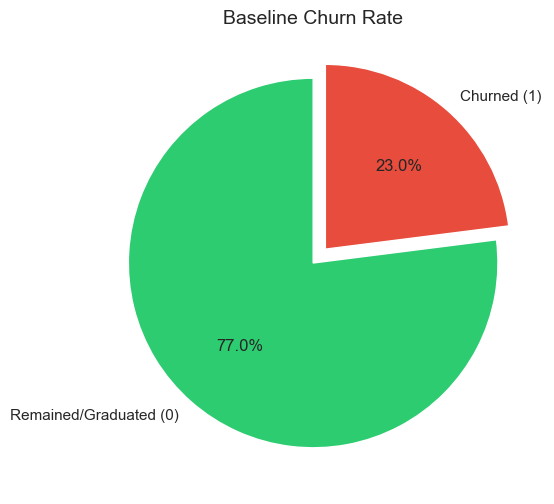

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

churn_counts = df_students['is_churned'].value_counts()

ax.pie(
    churn_counts,
    labels=['Remained/Graduated (0)', 'Churned (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c'],
    explode=(0, 0.1))


ax.set_title('Baseline Churn Rate', fontsize=14)

plt.show()

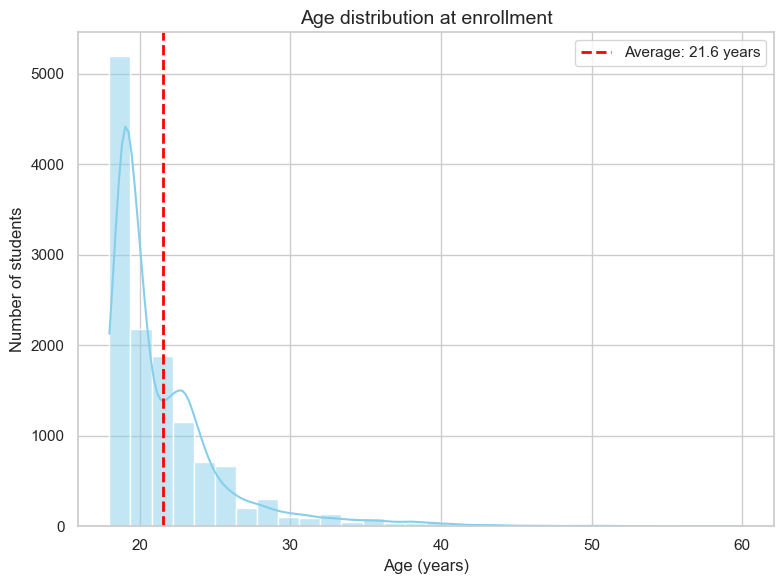

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=df_students,
    x='age_at_enrollment',
    bins=30,
    kde=True,
    ax=ax,
    color='skyblue'
)

ax.set_title('Age distribution at enrollment', fontsize=14)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of students')

mean_age = df_students['age_at_enrollment'].mean()

ax.axvline(
    mean_age,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Average: {mean_age:.1f} years')


ax.legend()

plt.tight_layout()
plt.show()

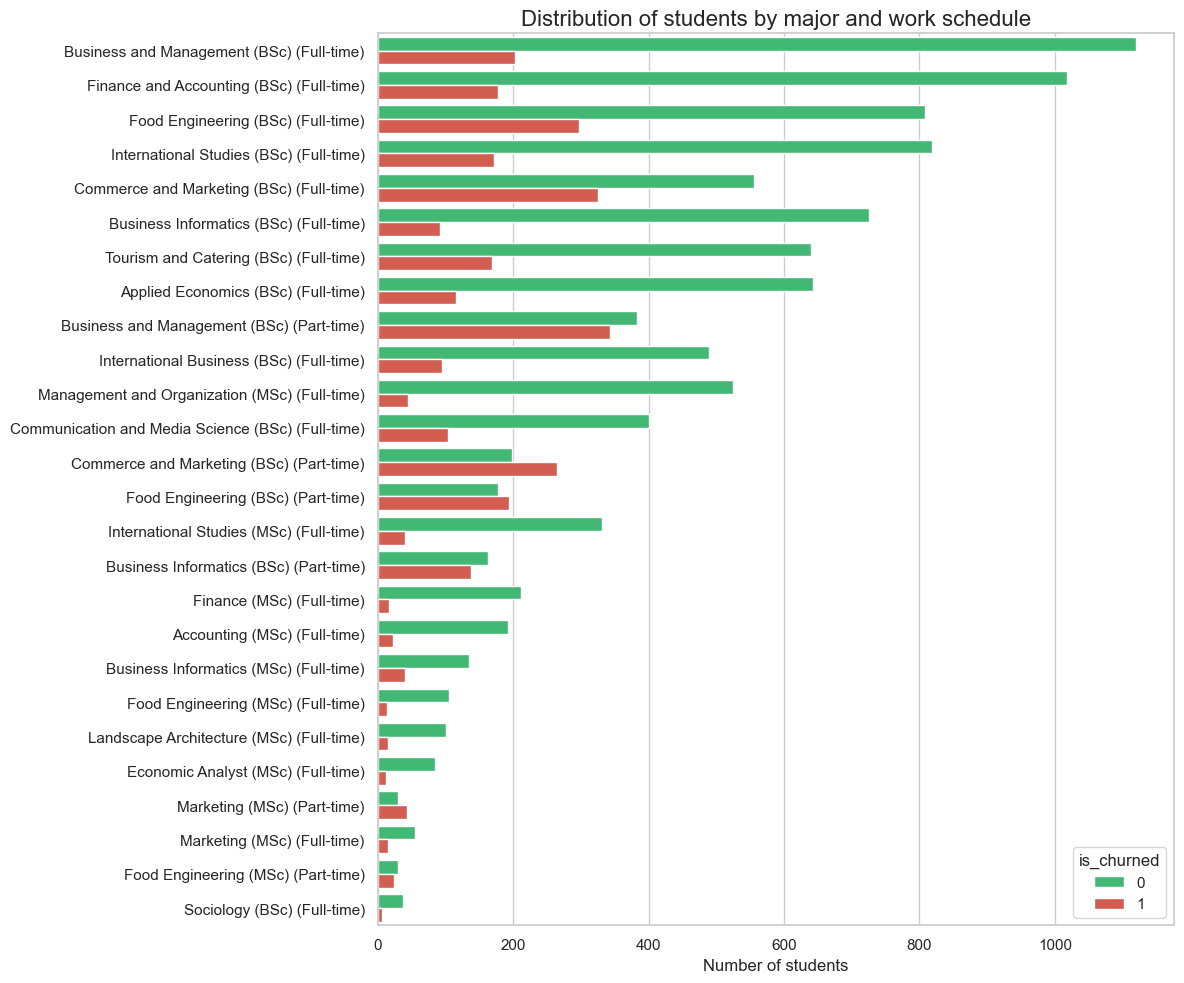

In [5]:
df_students['major_with_mode'] = df_students['major_name_en'] + " (" + df_students['study_mode'] + ")"

fig, ax = plt.subplots(figsize=(12, 10))

sns.countplot(
    data=df_students,
    y='major_with_mode',
    hue='is_churned',
    order=df_students['major_with_mode'].value_counts().index,
    palette=['#2ecc71', '#e74c3c'],
    ax=ax)


ax.set_title('Distribution of students by major and work schedule', fontsize=16)
ax.set_xlabel('Number of students')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

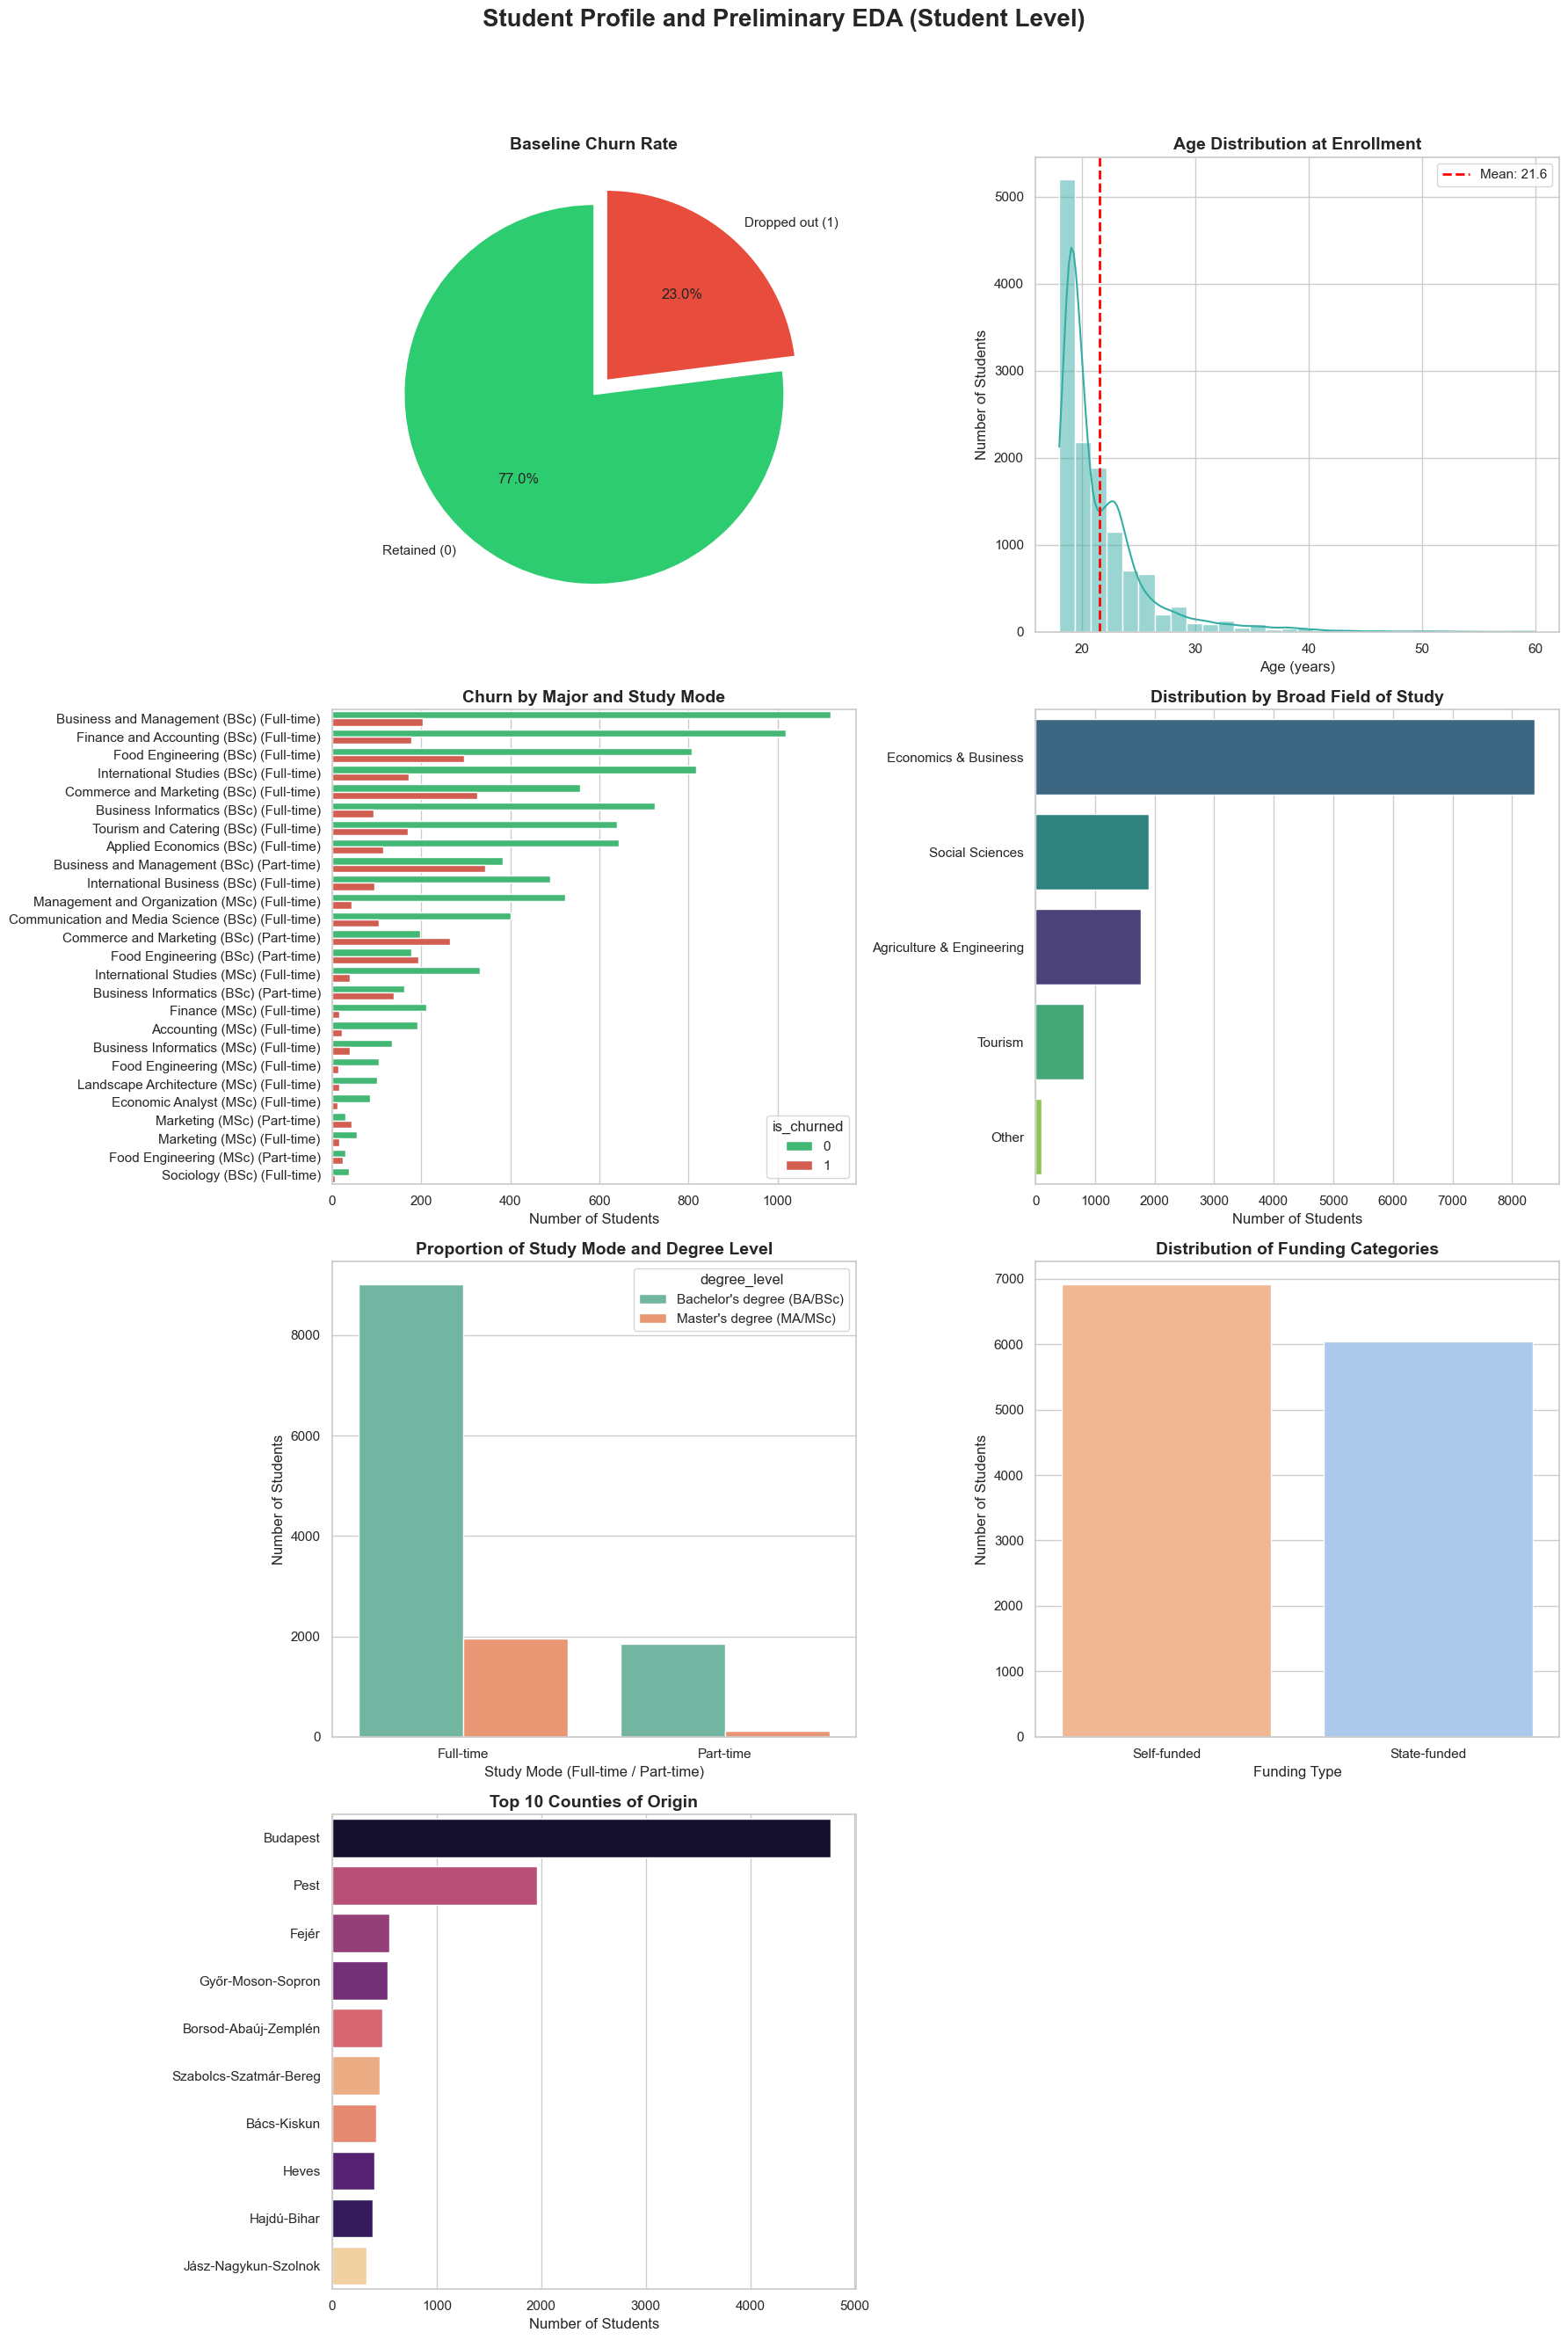

In [26]:
fig, axes = plt.subplots(4, 2, figsize=(18, 28))
fig.suptitle('Student Profile and Preliminary EDA (Student Level)', fontsize=20, fontweight='bold', y=0.98)

# --- 1. Figure: Baseline Churn Rate ---
churn_counts = df_students['is_churned'].value_counts()
axes[0, 0].pie(churn_counts, labels=['Retained (0)', 'Dropped out (1)'], 
                autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[0, 0].set_title('Baseline Churn Rate', fontsize=14, fontweight='bold')

# --- 2. Figure: Age at Enrollment ---
sns.histplot(data=df_students, x='age_at_enrollment', bins=30, kde=True, ax=axes[0, 1], color=palette[4])
axes[0, 1].set_title('Age Distribution at Enrollment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Number of Students')
mean_age = df_students['age_at_enrollment'].mean()
axes[0, 1].axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_age:.1f}')
axes[0, 1].legend()

# --- 3. Figure: Major with Study Mode and Churn ---
sns.countplot(data=df_students, y='major_with_mode', hue='is_churned', 
              order=df_students['major_with_mode'].value_counts().index,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Churn by Major and Study Mode', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Students')
axes[1, 0].set_ylabel('')

# --- 4. Figure: Fields of Study (Broad) ---
sns.countplot(data=df_students, y='major_field_broad', hue='major_field_broad',
              ax=axes[1, 1], order=df_students['major_field_broad'].value_counts().index, 
              palette='viridis', legend=False)
axes[1, 1].set_title('Distribution by Broad Field of Study', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Students')
axes[1, 1].set_ylabel('')

# --- 5. Figure: Study Mode and Degree Level ---
sns.countplot(data=df_students, x='study_mode', hue='degree_level', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Proportion of Study Mode and Degree Level', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Study Mode (Full-time / Part-time)')
axes[2, 0].set_ylabel('Number of Students')

# --- 6. Figure: Funding Category ---
sns.countplot(data=df_students, x='funding_category', hue='funding_category',
              ax=axes[2, 1], palette='pastel', legend=False,
              order=df_students['funding_category'].value_counts().index)
axes[2, 1].set_title('Distribution of Funding Categories', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Funding Type')
axes[2, 1].set_ylabel('Number of Students')

# --- 7. Figure: Top 10 Counties of Origin ---
top_counties = df_students['county'].value_counts().nlargest(10).index
sns.countplot(data=df_students[df_students['county'].isin(top_counties)], y='county', 
              hue='county', ax=axes[3, 0], order=top_counties, palette='magma', legend=False)
axes[3, 0].set_title('Top 10 Counties of Origin', fontsize=14, fontweight='bold')
axes[3, 0].set_xlabel('Number of Students')
axes[3, 0].set_ylabel('')

axes[3, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3.0 Performance Mapping (Fundamentals of Dynamic Variables)

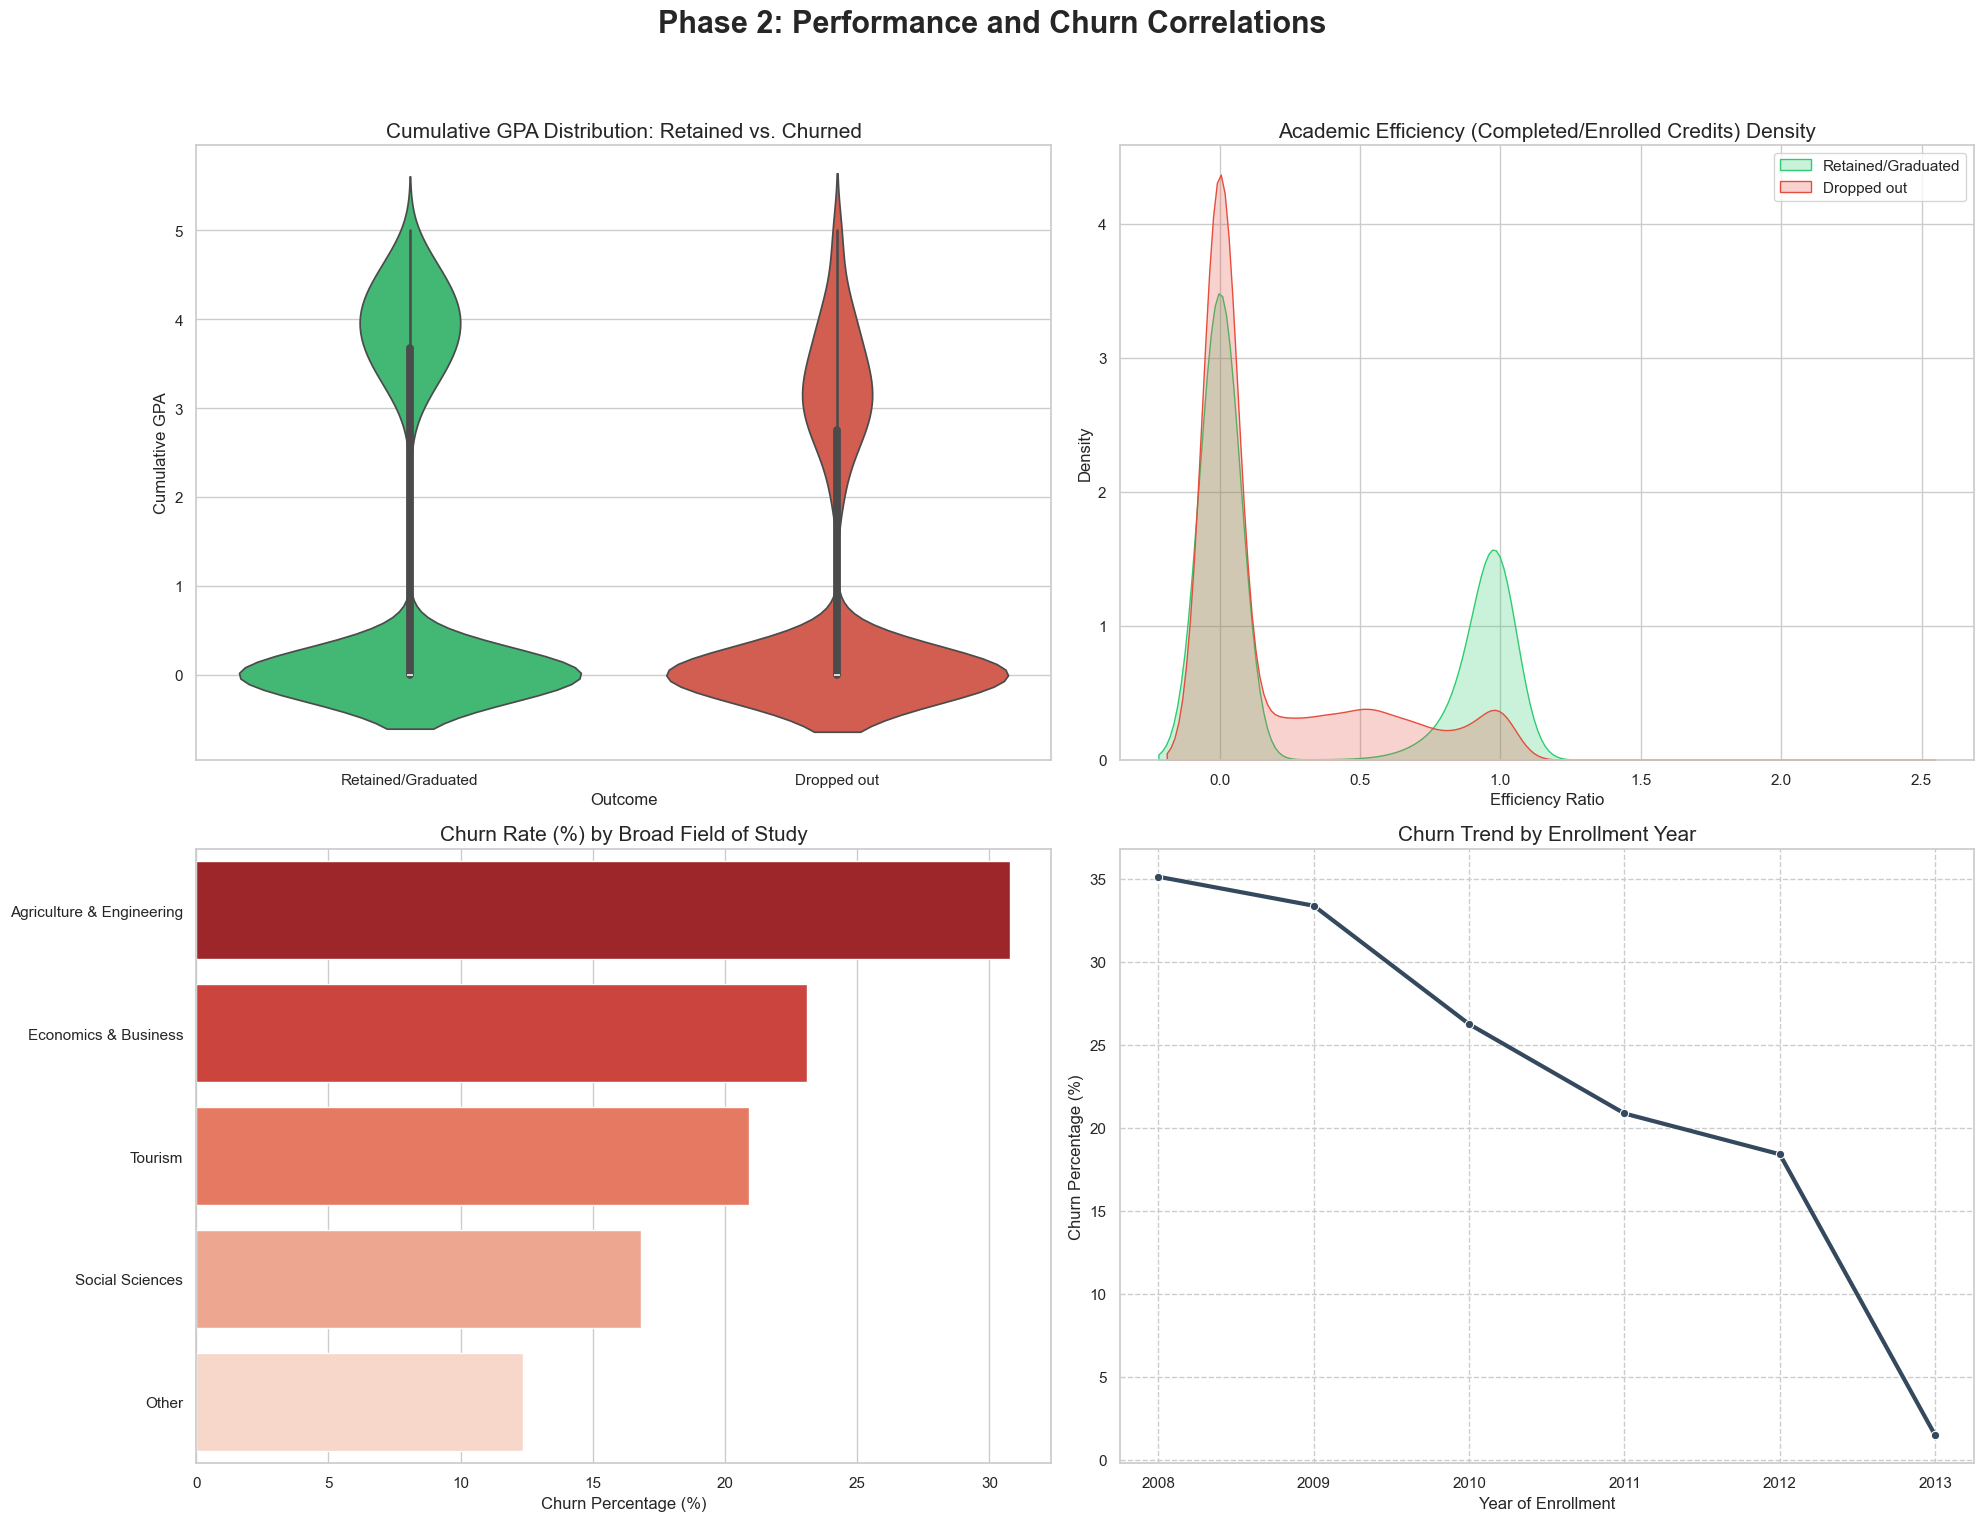


--- Churn Rate (%) by Study Mode and Funding Category ---
funding_category  Self-funded  State-funded
study_mode                                 
Full-time               20.84         15.49
Part-time               51.43         43.37


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Phase 2: Performance and Churn Correlations', fontsize=22, fontweight='bold')

# --- Figure 1: GPA Distribution by Outcome (Violin Plot) ---
sns.violinplot(data=df_students, x='is_churned', y='gpa_cum', hue='is_churned', 
               ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'], legend=False)
axes[0, 0].set_title('Cumulative GPA Distribution: Retained vs. Churned', fontsize=15)

# FIX: Set ticks before setting labels to avoid UserWarning
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Retained/Graduated', 'Dropped out'])
axes[0, 0].set_xlabel('Outcome')
axes[0, 0].set_ylabel('Cumulative GPA')

# --- Figure 2: Academic Efficiency vs. Churn ---
sns.kdeplot(data=df_students[df_students['is_churned'] == 0]['academic_efficiency'], 
            label='Retained/Graduated', ax=axes[0, 1], fill=True, color='#2ecc71')
sns.kdeplot(data=df_students[df_students['is_churned'] == 1]['academic_efficiency'], 
            label='Dropped out', ax=axes[0, 1], fill=True, color='#e74c3c')
axes[0, 1].set_title('Academic Efficiency (Completed/Enrolled Credits) Density', fontsize=15)
axes[0, 1].set_xlabel('Efficiency Ratio')
axes[0, 1].legend()

# --- Figure 3: Churn Rate per Broad Field of Study ---
major_churn = df_students.groupby('major_field_broad')['is_churned'].mean().sort_values(ascending=False) * 100
sns.barplot(x=major_churn.values, y=major_churn.index, hue=major_churn.index, 
            ax=axes[1, 0], palette='Reds_r', legend=False)
axes[1, 0].set_title('Churn Rate (%) by Broad Field of Study', fontsize=15)
axes[1, 0].set_xlabel('Churn Percentage (%)')
axes[1, 0].set_ylabel('')

# --- Figure 4: Churn Rate by Enrollment Year / Timeline ---
year_churn = df_students.groupby('enrollment_year')['is_churned'].mean() * 100
sns.lineplot(x=year_churn.index, y=year_churn.values, marker='o', ax=axes[1, 1], color='#34495e', linewidth=3)
axes[1, 1].set_title('Churn Trend by Enrollment Year', fontsize=15)
axes[1, 1].set_xlabel('Year of Enrollment')
axes[1, 1].set_ylabel('Churn Percentage (%)')
axes[1, 1].grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# EXTRA: Cross-tabulation of study mode and funding effect
print("\n--- Churn Rate (%) by Study Mode and Funding Category ---")
pivot = df_students.pivot_table(index='study_mode', columns='funding_category', values='is_churned', aggfunc='mean') * 100
print(pivot.round(2))